In [1]:
from matplotlib.backends.backend_pdf import PdfPages
from src.sgtlib.utils.sgt_utils import sgt_excel_to_dataframe, sgt_scaling_plot

# Uncomment to install Libraries (if not installed)
#!pip3 install openpyxl

In [2]:
# Read the Excel files and save in one DataFrame
allowed_ext = ".xlsx"
excel_dir_path = "n_100/"
pdf_file = "n_100/scaling_results-100.pdf"
plt_figs = []

all_sheets = sgt_excel_to_dataframe(excel_dir_path, allowed_ext)

In [3]:
# Filter the relevant materials and parameters
materials = {'BSE 017', 'BSE 011', 'BSE 024', 'BSE 025'}
material_names = ['PAN/CGO', 'Carb. PAN', 'PAN', 'Carb. PAN/CGO']
parameters = ['GD', 'BC', 'CC', 'EC']

material_labels = {key: name for (name, key) in zip(material_names, materials)}

Stretched power-law fit error: Optimal parameters not found: The maximum number of function evaluations is exceeded.


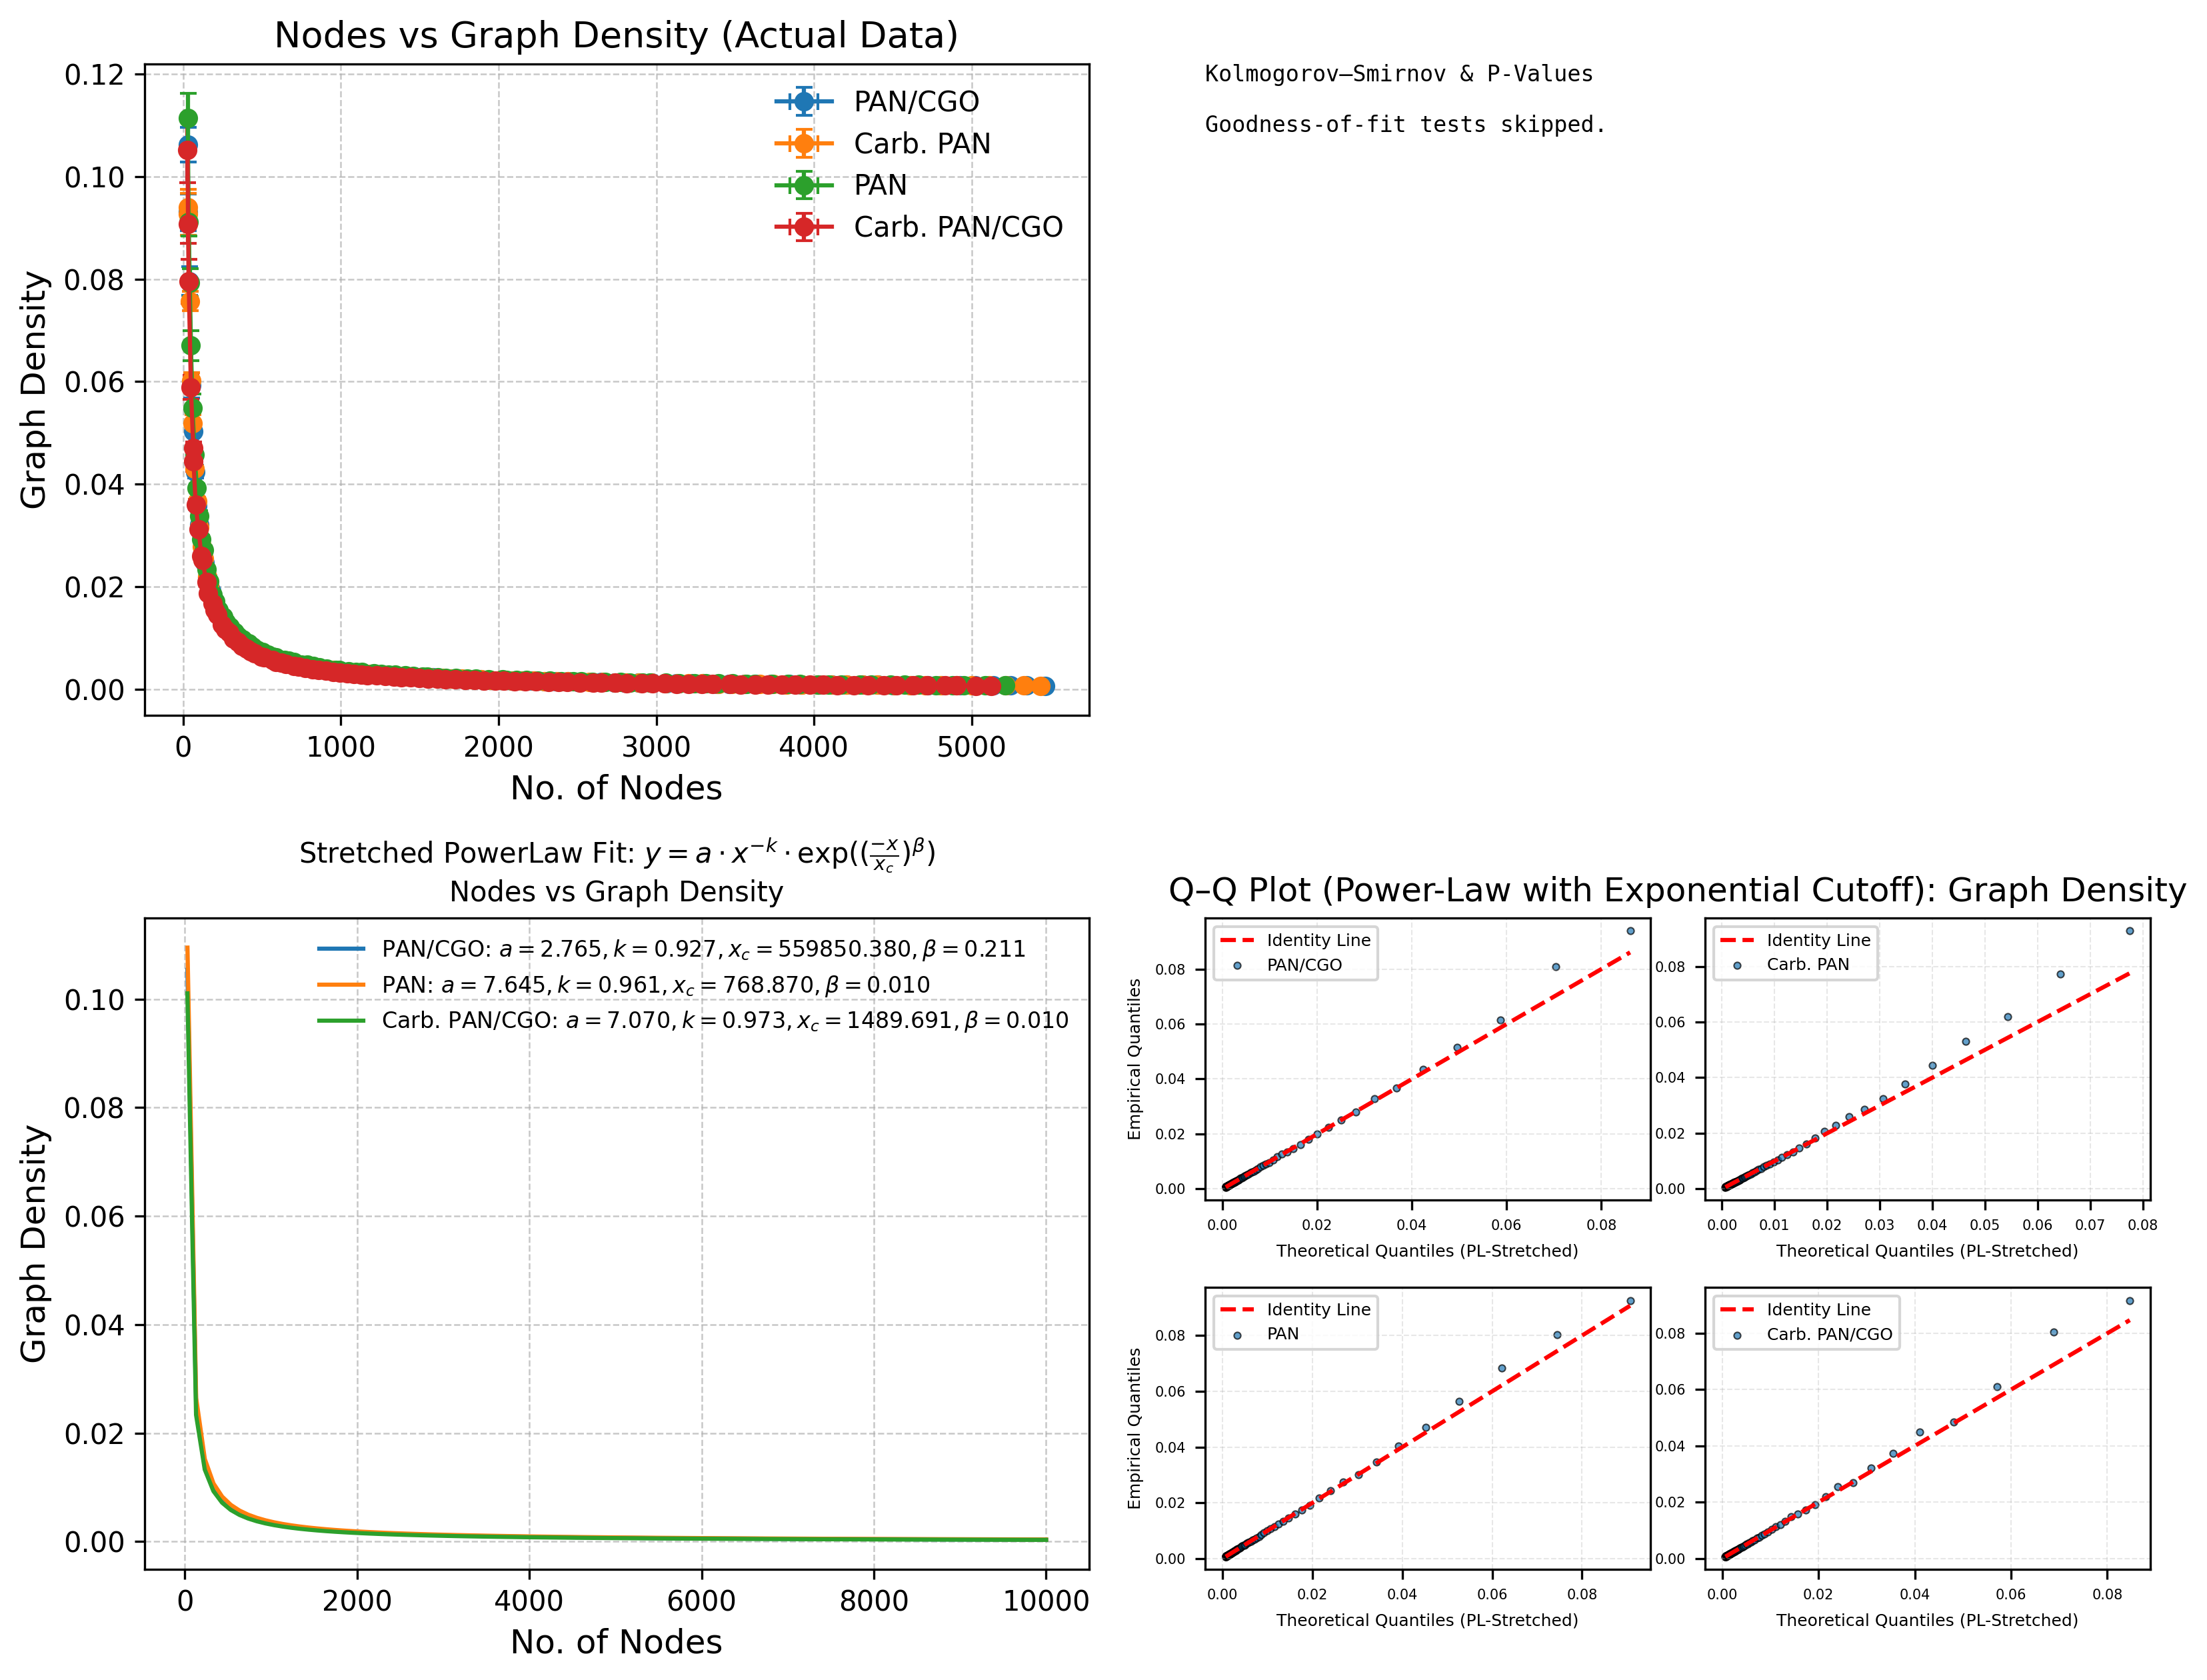

In [5]:
"""
Graph Density
"""
df_dens = all_sheets['Nodes-Density']
plt_fig = sgt_scaling_plot("Graph Density", df_dens, material_labels, skip_test=True, fit_func='powerlaw-ec')
plt_figs.append(plt_fig)

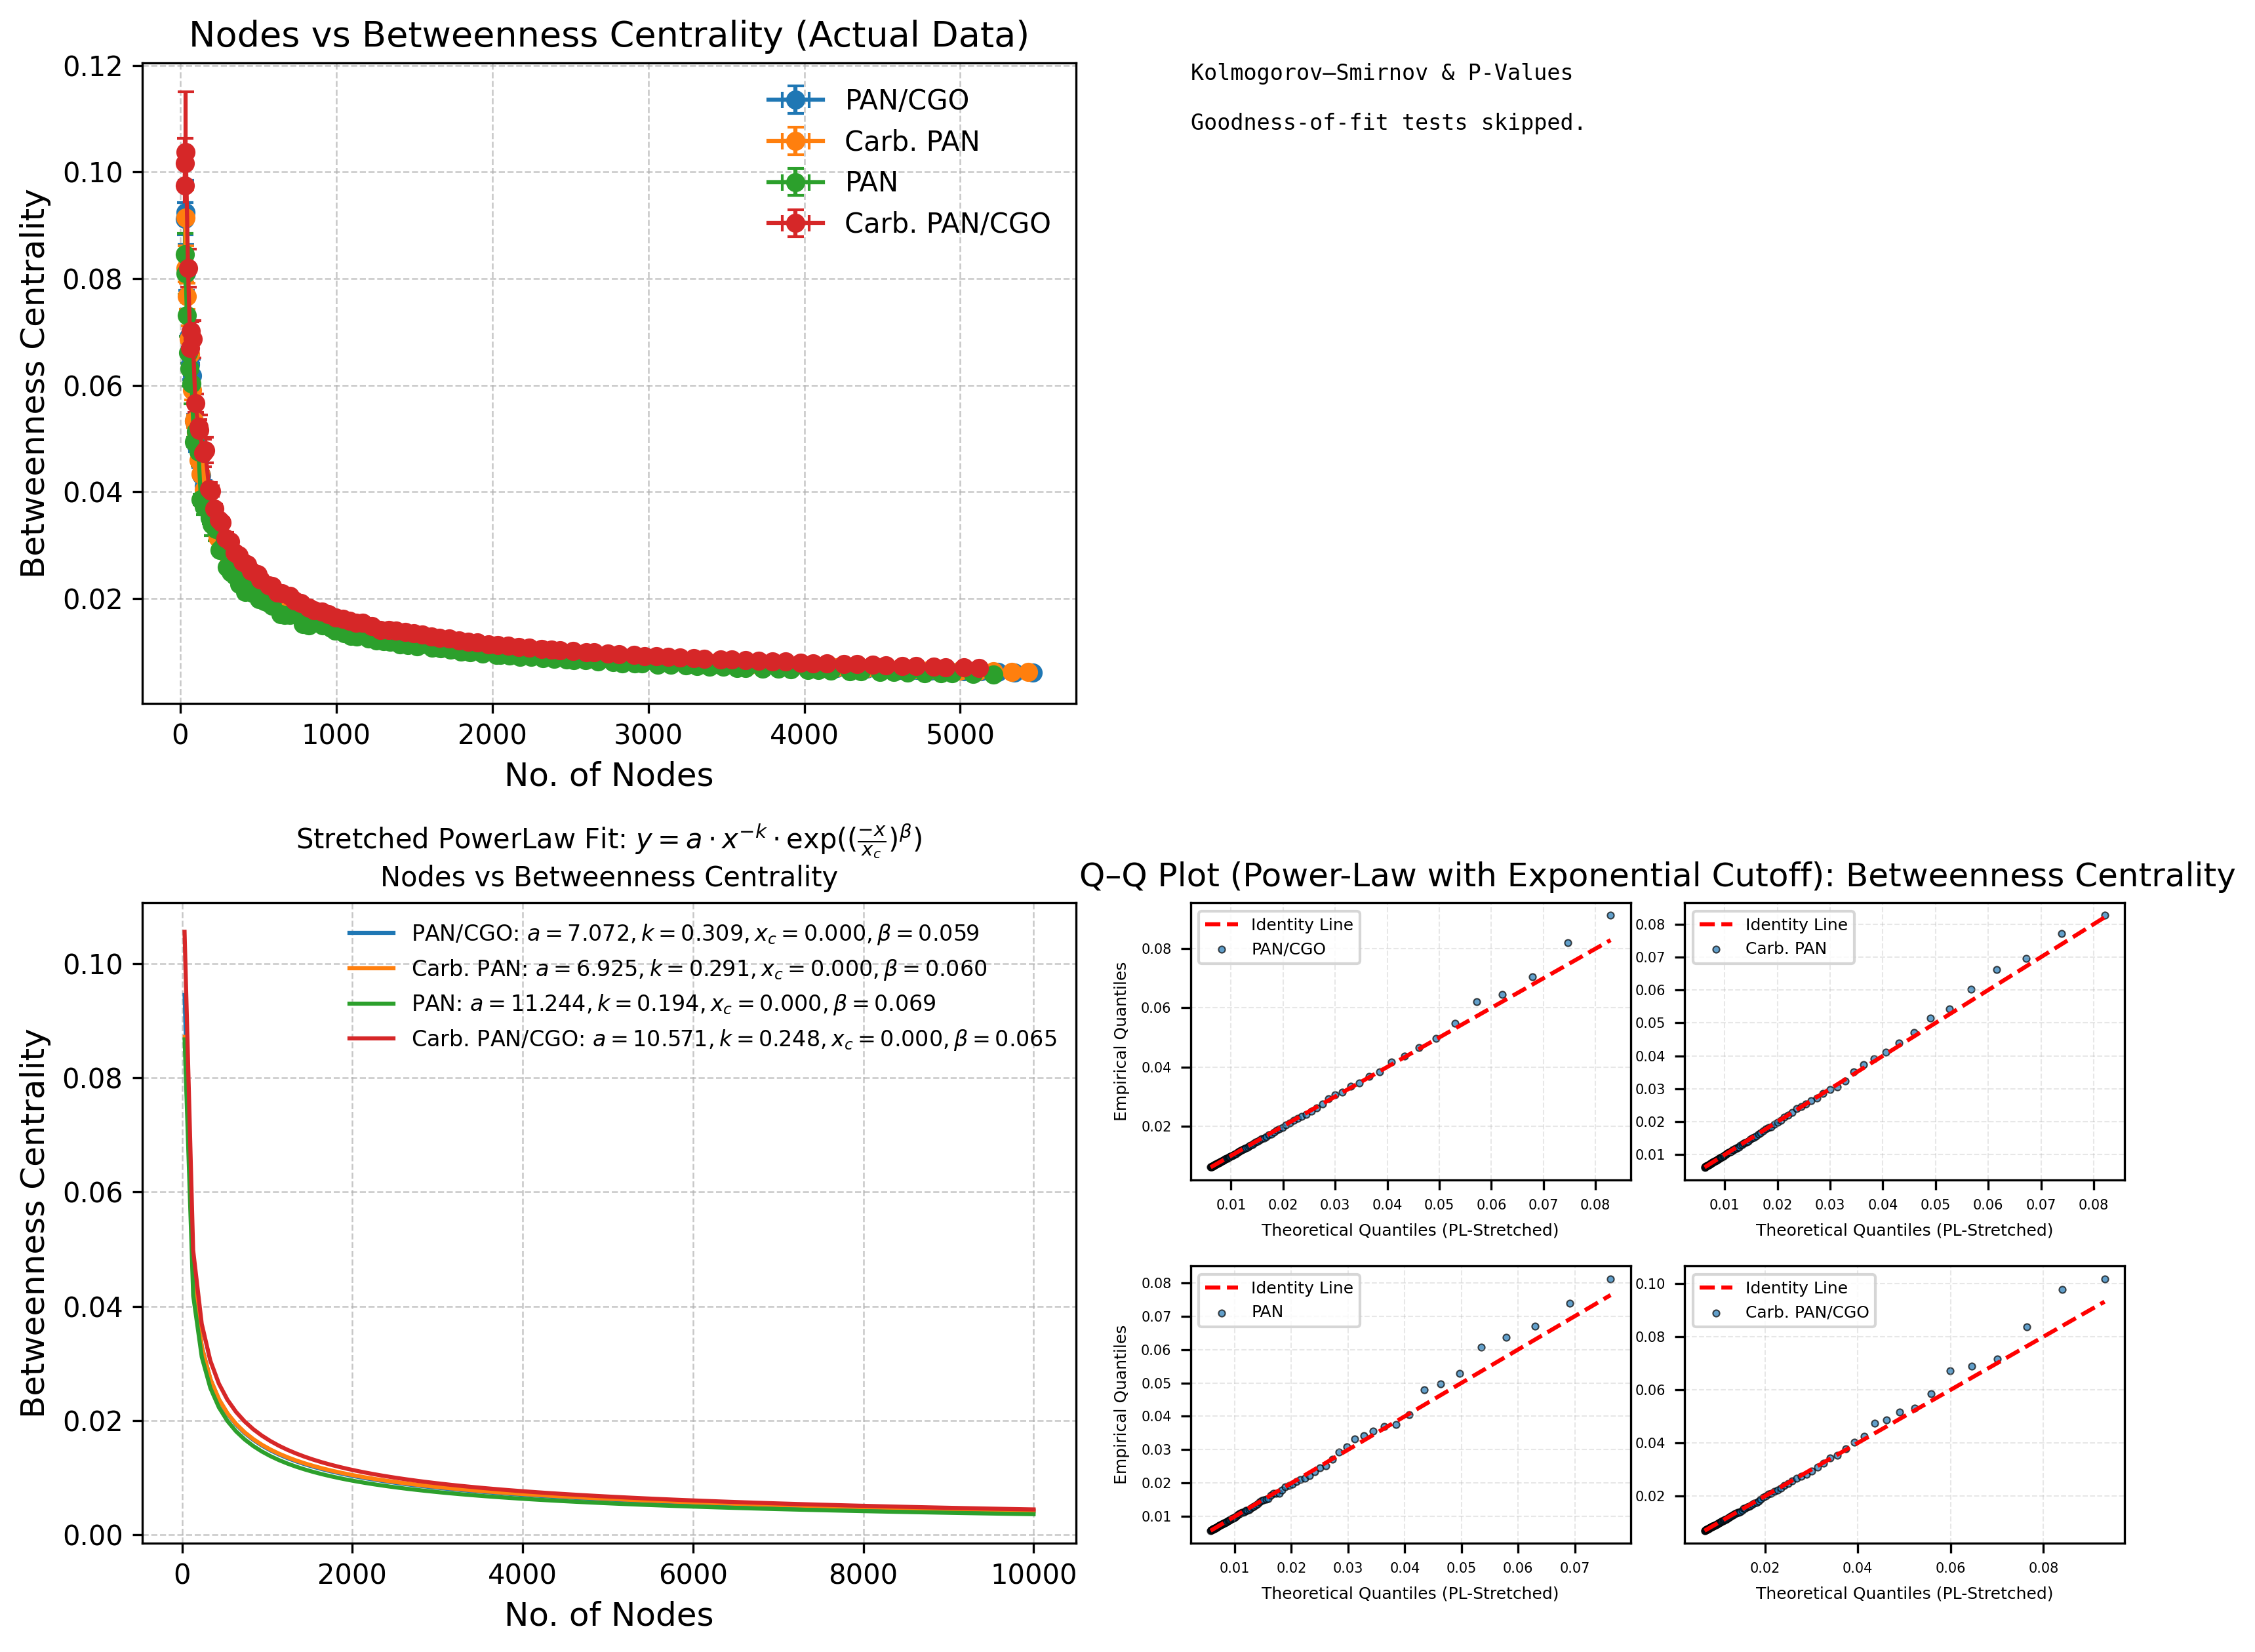

In [6]:
"""
Betweenness
"""
df_bet = all_sheets['Nodes-BC']
plt_fig = sgt_scaling_plot("Betweenness Centrality", df_bet, material_labels, skip_test=True, fit_func='powerlaw-ec')
plt_figs.append(plt_fig)

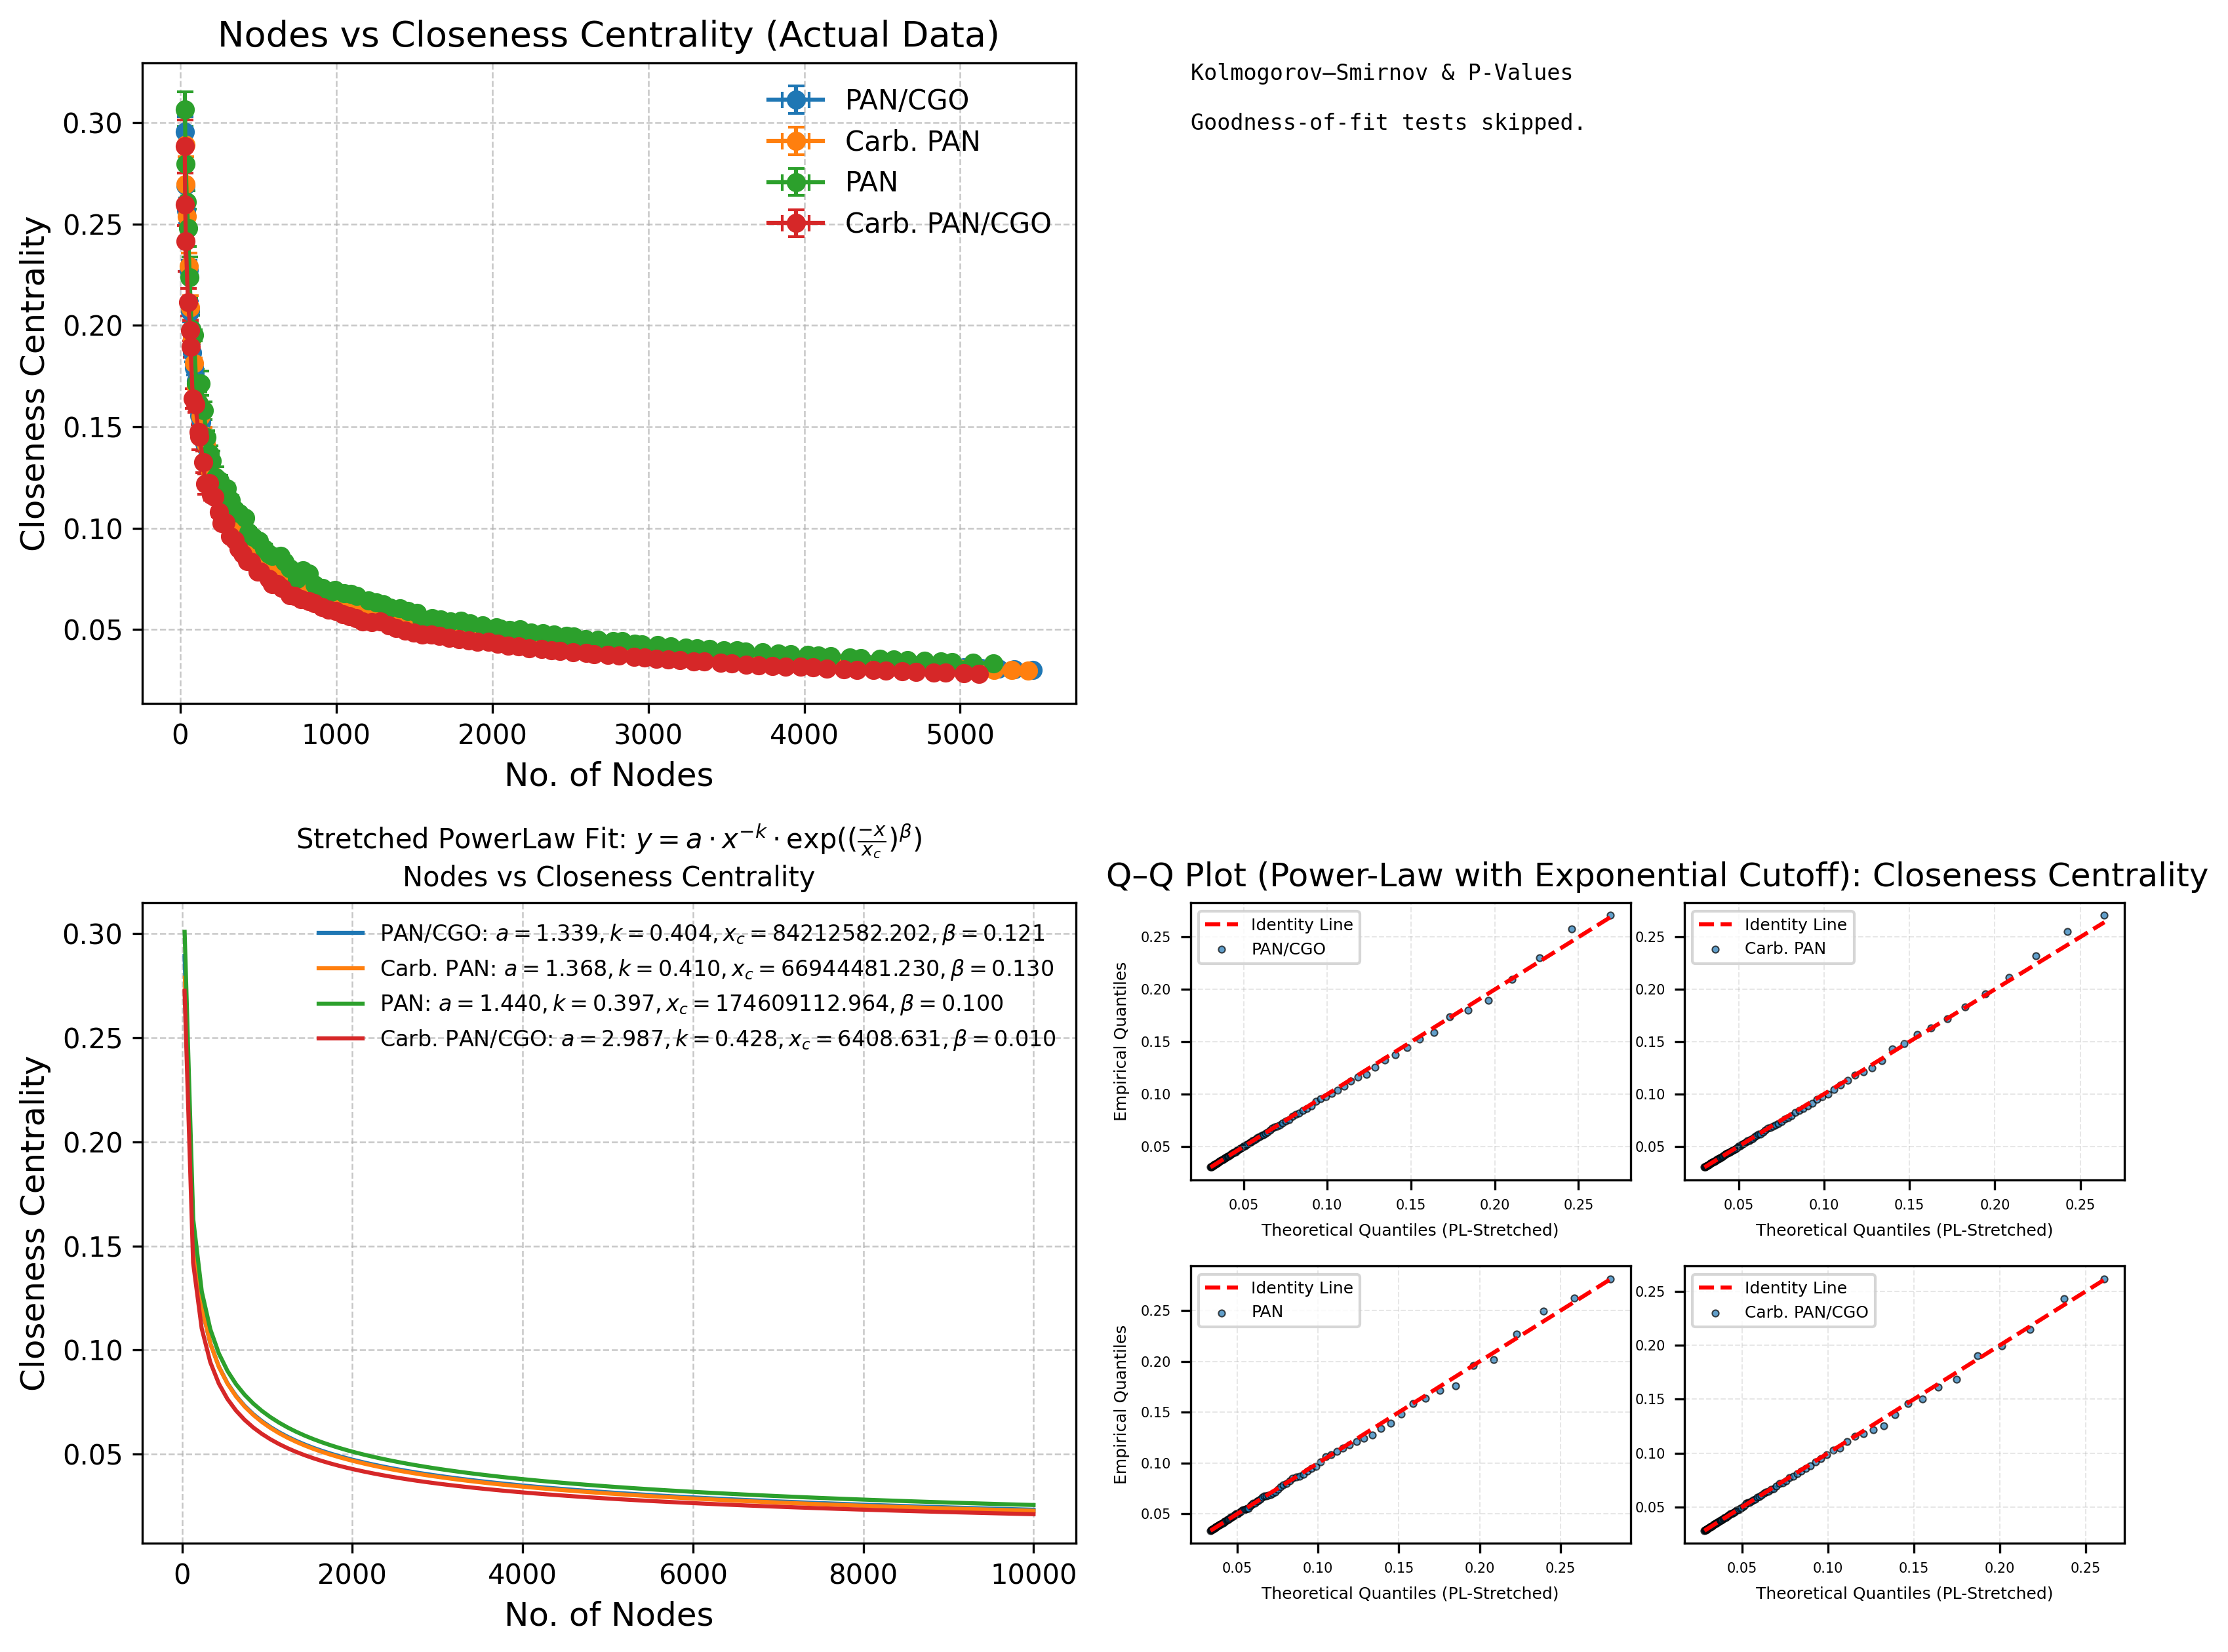

In [7]:
"""
Closeness
"""
df_clo = all_sheets['Nodes-CC']
plt_fig = sgt_scaling_plot("Closeness Centrality", df_clo, material_labels, skip_test=True, fit_func='powerlaw-ec')
plt_figs.append(plt_fig)

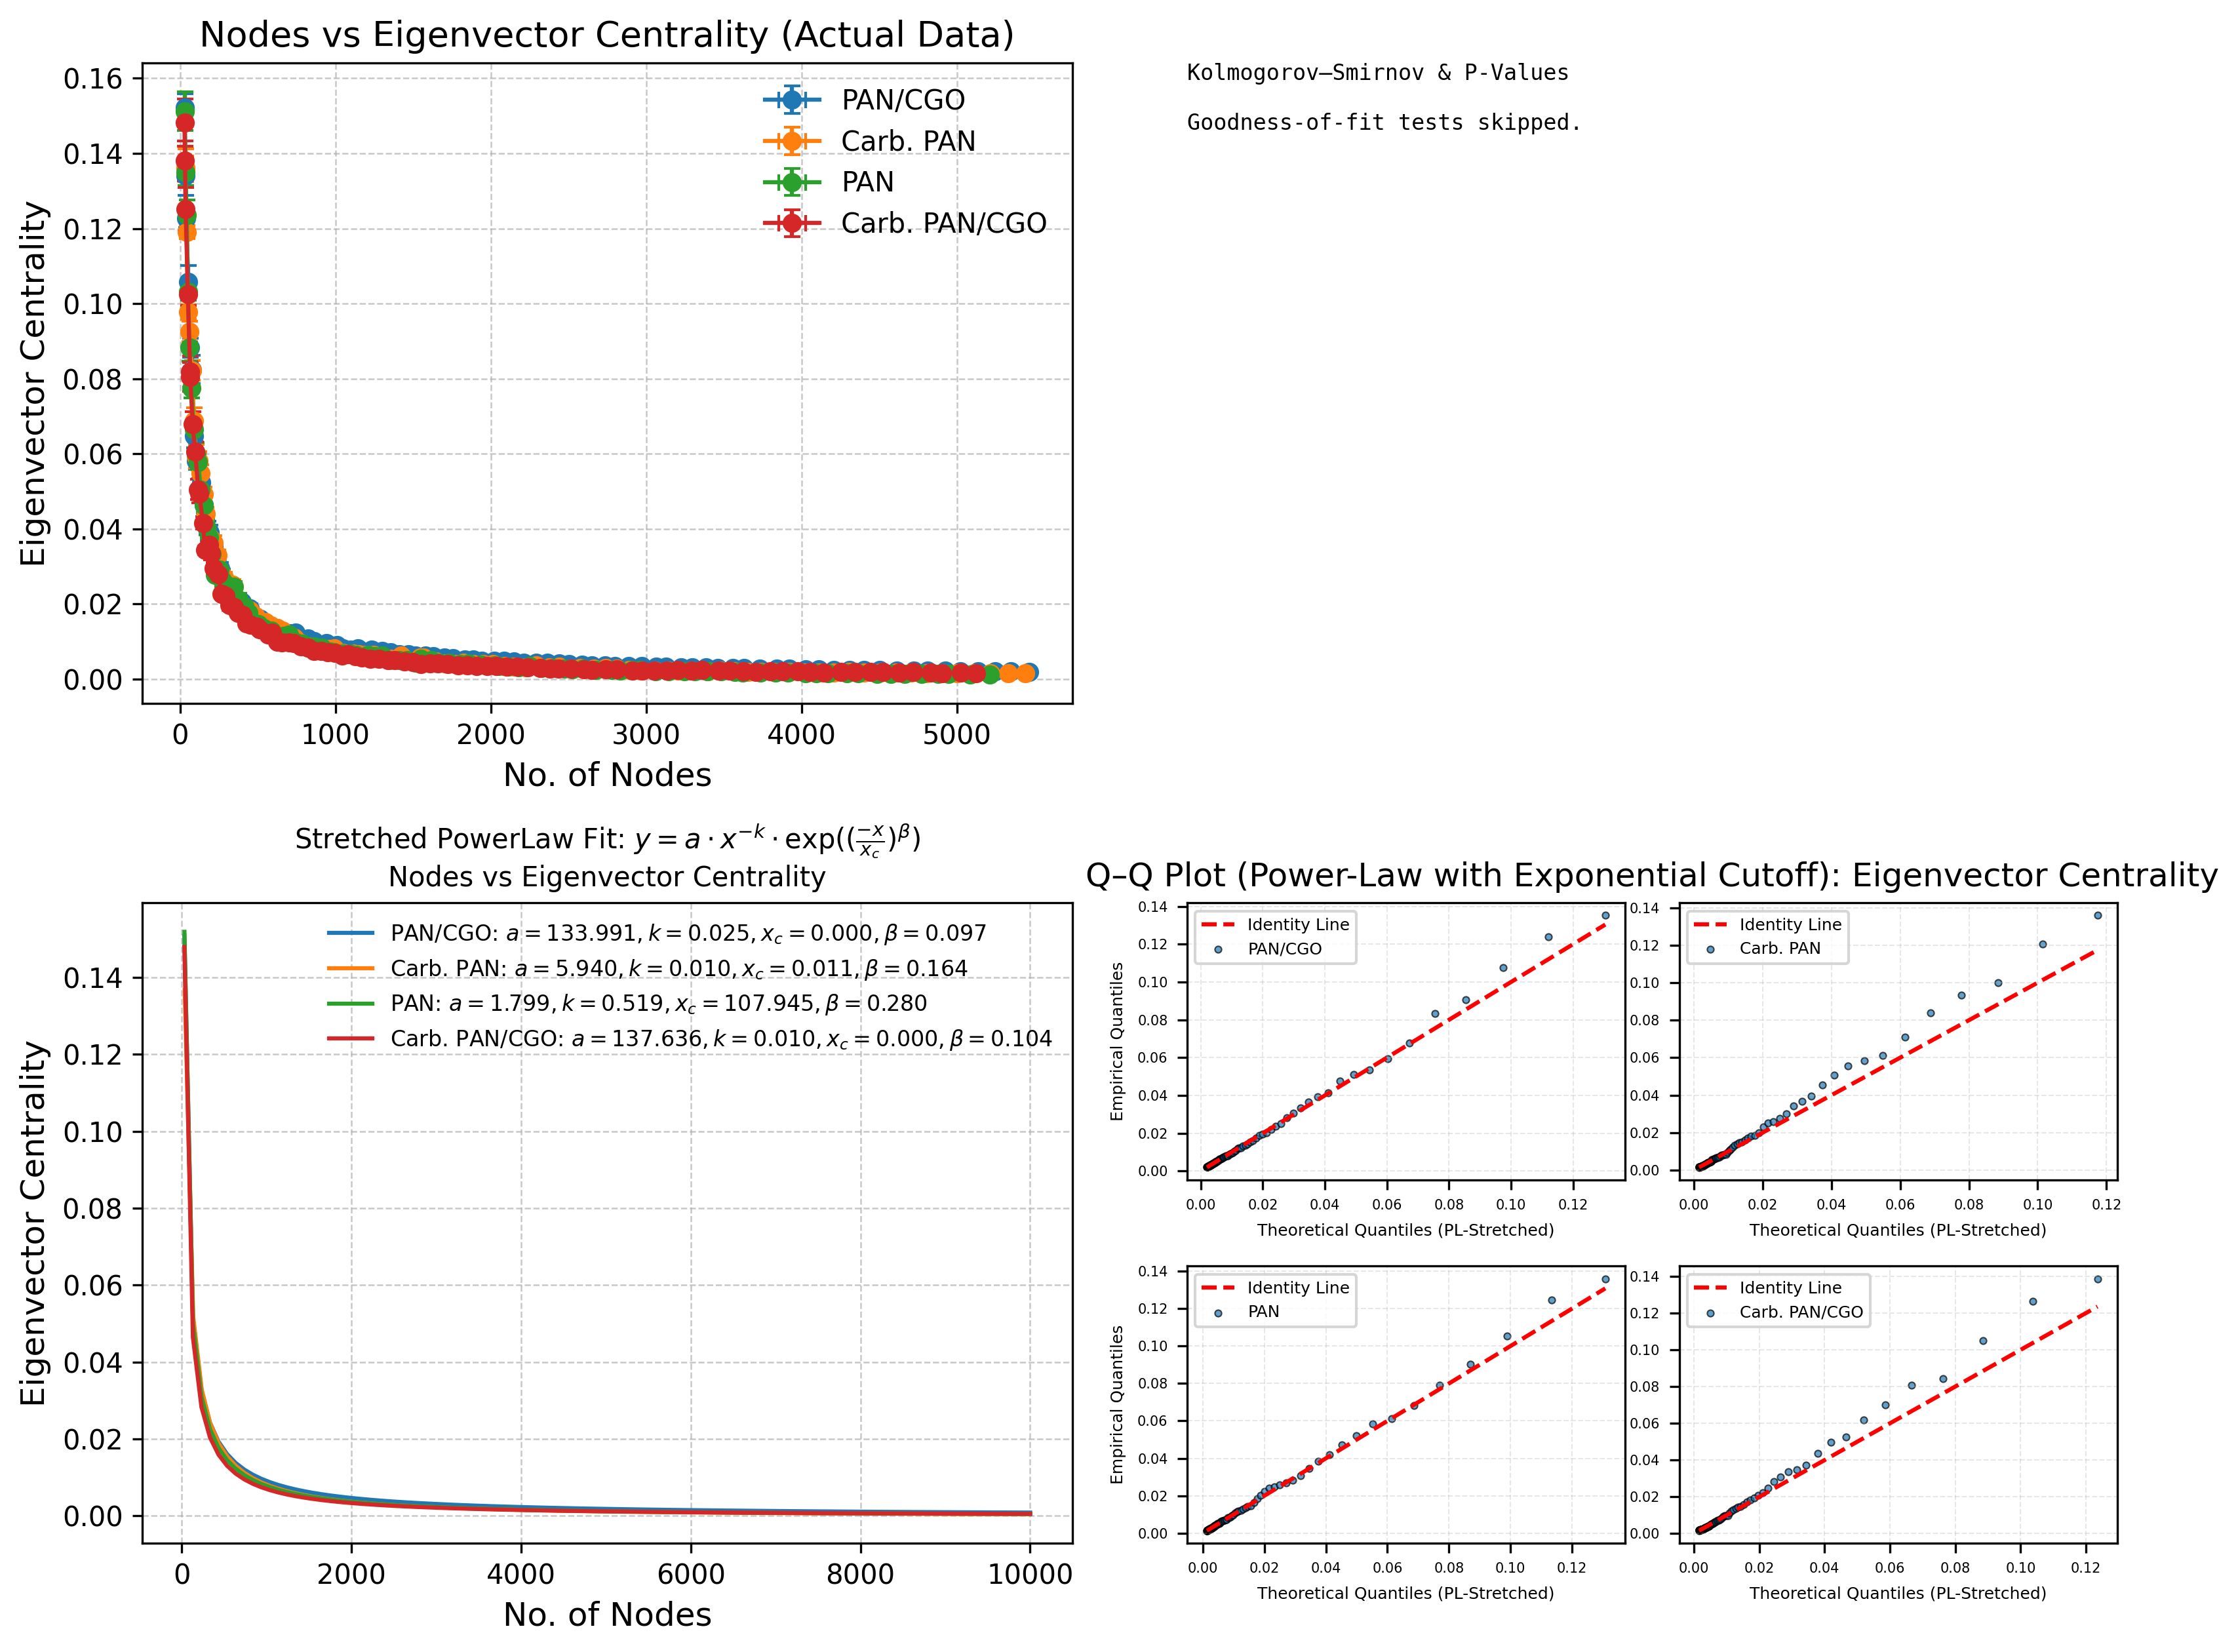

In [8]:
"""
Eigenvector
"""
df_eig = all_sheets['Nodes-EC']
plt_fig = sgt_scaling_plot("Eigenvector Centrality", df_eig, material_labels, skip_test=True, fit_func='powerlaw-ec')
plt_figs.append(plt_fig)


In [ ]:
with PdfPages(pdf_file) as pdf:
    for fig in plt_figs:
        pdf.savefig(fig)